In [3]:
# Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("default")
sns.set_context ("notebook")

In [4]:
customers = pd.read_csv("../data/raw/customers.csv")
customer_activity = pd.read_csv("../data/raw/customer_activity.csv")
promotions = pd.read_csv("../data/raw/promotions.csv")
promo_redemptions = pd.read_csv("../data/raw/promo_redemptions.csv")
trips = pd.read_csv("../data/raw/trips.csv")

In [27]:
promotions.head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,usage_limit
0,PROMO0000,Christmas Bonus,flat,12.28,24/10/2025,14/12/2025,4463
1,PROMO0001,Christmas Bonus,loyalty,23.00,30/01/2023,23/02/2023,1180
2,PROMO0002,Back to School,flat,3.18,31/05/2024,15/07/2024,2178
3,PROMO0003,Spring Break,percentage,20.00,26/02/2023,06/04/2023,537
4,PROMO0004,Black Friday,flat,4.76,19/12/2024,21/01/2025,226


In [6]:
trips.head()

,trip_id,customer_id,driver_id,city,pickup_area,dropoff_area,trip_datetime,trip_status,distance_km,duration_min,fare_amount,platform_revenue,driver_payout,promo_used,surge_multiplier
0,TRIP0000001,CUST00000,DRV9390,London,Shoreditch,Camden,2025-06-04 18:36:00,completed,6.24,15.0,21.020,5.26,15.76,0,1.0
1,TRIP0000002,CUST00000,DRV5967,London,Brixton,Hackney,2025-06-04 14:03:00,completed,3.40,37.4,20.270,5.07,15.20,0,1.5
2,TRIP0000003,CUST00000,DRV1592,London,Kensington,Brixton,2025-12-13 07:19:00,completed,2.47,24.8,10.630,2.66,7.97,1,1.0
3,TRIP0000004,CUST00000,DRV6016,London,Hackney,Greenwich,2025-07-22 07:12:00,completed,2.69,37.8,18.510,4.63,13.88,0,1.0
4,TRIP0000005,CUST00000,DRV1139,London,Canary Wharf,Greenwich,2024-11-06 17:22:00,cancelled,9.58,19.9,2.232,0.56,1.67,0,1.0


In [7]:
promo_redemptions.head()

,trip_id,customer_id,promo_id,promo_name,redeemed_date,promo_cost
0,TRIP0032098,CUST00760,PROMO0038,Black Friday,05/06/2025,9.91
1,TRIP0118751,CUST02816,PROMO0016,Holiday Rush,01/04/2024,7.58
2,TRIP0040302,CUST00951,PROMO0013,Senior Special,16/10/2025,9.67
3,TRIP0042431,CUST01000,PROMO0023,Student Discount,07/09/2025,8.38
4,TRIP0031258,CUST00740,PROMO0000,Christmas Bonus,25/10/2025,8.36


In [8]:
customers.head()

,customer_id,first_name,last_name,email,phone,city,signup_date,age,gender,total_trips,cancelled_trips,days_since_last_trip,churned,engagement_score,loyalty_score,persona,signup_channel,income_level,payment_method,device_type
0,CUST00000,Adrian,Walker,adrian.walker@gmail.com,020 7946 0251,London,27/04/2024,19,Other,63,7,20,0,1.0,0.994,Tourist,Ads,high,Debit Card,iOS
1,CUST00001,Tony,Jones,tony.jones@hotmail.co.uk,4.41165E+11,London,01/10/2023,61,Other,52,0,44,0,1.0,0.925,Business,Partnership,high,Credit Card,iOS
2,CUST00002,Lynn,Carter,lynn.carter@outlook.com,+44(0)20 7496 0628,London,22/01/2025,31,Male,47,1,4,0,1.0,0.894,Business,Ads,high,Cash,iOS
3,CUST00003,Marcelo,Madrigal,marcelo.madrigal@hotmail.com,+34987 210 730,Barcelona,01/03/2025,55,Female,44,3,7,0,1.0,0.875,Business,Ads,low,Cash,Android
4,CUST00004,Faye,Strik,faye.strik@hotmail.com,086 1284110,Amsterdam,13/09/2025,27,Male,30,2,33,0,1.0,0.787,Tourist,Referral,medium,Credit Card,Android


In [9]:
customer_activity.head()

,customer_id,session_id,event_date,event_type
0,CUST00000,3d58b027-5ab8-4cc7-b9cb-4690cc0b5428,2025-08-27,app_open
1,CUST00000,3d58b027-5ab8-4cc7-b9cb-4690cc0b5428,2025-08-27,search
2,CUST00000,3d58b027-5ab8-4cc7-b9cb-4690cc0b5428,2025-08-27,ride_request
3,CUST00000,acce0654-fdeb-4c2b-9ad2-9f0b46749356,2025-08-31,app_open
4,CUST00000,7ccae9a7-50e0-4c6f-8ebf-ea76cce0e307,2025-12-08,app_open


In [10]:
# this is checking missing values 

In [11]:
customers.isna().sum()
customer_activity.isna().sum()
promotions.isna().sum() 
promo_redemptions.isna().sum()
trips.isna().sum()


trip_id                0
customer_id            0
driver_id              0
city                   0
pickup_area            0
dropoff_area           0
trip_datetime          0
trip_status            0
distance_km         3801
duration_min        3801
fare_amount            0
platform_revenue       0
driver_payout          0
promo_used             0
surge_multiplier       0
dtype: int64

In [12]:
trips.loc[
    trips["distance_km"].isna(),
    "trip_status"
].value_counts()


trip_status
completed    3326
cancelled     475
Name: count, dtype: int64

In [13]:
customers.duplicated().sum()
customer_activity.duplicated().sum()
promotions.duplicated().sum()
promo_redemptions.duplicated().sum()
trips.duplicated().sum()

np.int64(0)

In [14]:
#Dataset relationships and aggreagation
customers.shape, trips.shape, customer_activity.shape, promotions.shape, promo_redemptions.shape


((3000, 20), (126703, 15), (485985, 4), (40, 7), (11394, 6))

In [15]:
trips_per_customer = (
    trips.groupby("customer_id")
    .size()
    .reset_index(name="total_trips")
)

trips_per_customer.head()


,customer_id,total_trips
0,CUST00000,63
1,CUST00001,52
2,CUST00002,47
3,CUST00003,44
4,CUST00004,30


In [17]:
customers = customers.merge(
    trips_per_customer,
    on="customer_id",
    how="left"
).fillna({"total_trips": 0})

customers[["customer_id", "total_trips"]].head()


,customer_id,total_trips
0,CUST00000,63
1,CUST00001,52
2,CUST00002,47
3,CUST00003,44
4,CUST00004,30


In [18]:
trip_status_counts = (
    trips.groupby(["customer_id", "trip_status"])
    .size()
    .unstack(fill_value=0)
)

trip_status_counts.head()


trip_status,cancelled,completed
customer_id,,
CUST00000,9,54
CUST00001,4,48
CUST00002,2,45
CUST00003,6,38
CUST00004,4,26


In [19]:
trip_status_counts["cancellation_rate"] = (
    trip_status_counts.get("cancelled", 0) /
    (trip_status_counts.sum(axis=1))
)

trip_status_counts = trip_status_counts.reset_index()


In [20]:
customers = customers.merge(
    trip_status_counts[["customer_id", "cancellation_rate"]],
    on="customer_id",
    how="left"
).fillna({"cancellation_rate": 0})

customers[["customer_id", "cancellation_rate"]].head()


,customer_id,cancellation_rate
0,CUST00000,0.142857
1,CUST00001,0.076923
2,CUST00002,0.042553
3,CUST00003,0.136364
4,CUST00004,0.133333


In [24]:
customers.groupby("churned")[["total_trips", "cancellation_rate"]].mean()


,total_trips,cancellation_rate
churned,,
0,42.219094,0.125371
1,42.302368,0.128499


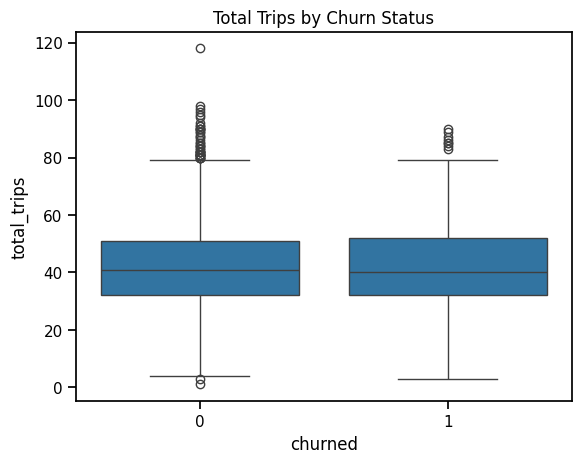

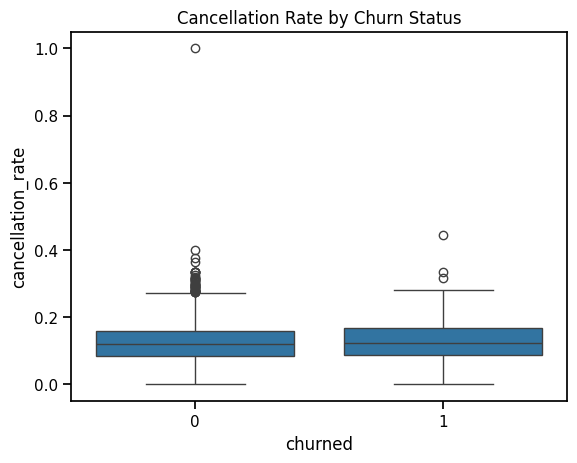

In [25]:


sns.boxplot(x="churned", y="total_trips", data=customers)
plt.title("Total Trips by Churn Status")
plt.show()

sns.boxplot(x="churned", y="cancellation_rate", data=customers)
plt.title("Cancellation Rate by Churn Status")
plt.show()
